In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
import timm # For EfficientNetV2-M
from timm.data import resolve_model_data_config, create_transform
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import requests
import shutil
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
import time

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Download and Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Filter Dataset to Keep Only Specified Classes

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/PlantVillage-Dataset'

if os.path.exists(dataset_path):
    classes = os.listdir(dataset_path)
    print(f"Classes in {dataset_path}:")
    print(classes)
    print(f"\nTotal number of classes: {len(classes)}")
else:
    print(f"Directory not found: {dataset_path}")

Classes in /content/drive/MyDrive/PlantVillage-Dataset:
['Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Apple___Apple_scab', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']

Total number of classes: 11


## 3. Data Preprocessing using torchvision.transforms

In [ ]:
# --------- Bangun model lebih dulu agar data_config selaras dengan model ----------
BATCH_SIZE = 8
NUM_WORKERS = 4
RNG_SEED = 42
# Catatan: untuk varian timm 'efficientnetv2_rw_m'
base_model = timm.create_model('efficientnetv2_rw_m', pretrained=True)

# Ambil konfigurasi data dari model (berisi input_size, mean, std, crop_pct, interpolation, dll.)
data_config = resolve_model_data_config(base_model)
print("data_config:", data_config)

# Buat transform training & validation sesuai resep timm
transform_train = create_transform(**data_config, is_training=True)
transform_val   = create_transform(**data_config, is_training=False)

data_config: {'input_size': (3, 320, 320), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 1.0, 'crop_mode': 'center'}


## 4. Load Data using torch.utils.data.DataLoader

In [ ]:
# --------- Siapkan dataset & split tanpa mendistorsi rasio ----------

# Penting: gunakan ImageFolder TANPA transform lebih dulu, lalu terapkan transform per-subset
base_dataset = datasets.ImageFolder(root=dataset_path)  # dataset_path harus sudah didefinisikan
class_names = base_dataset.classes
num_classes = len(class_names)
print(f"Jumlah kelas: {num_classes}")
print(f"Nama kelas: {class_names}")

# Buat indeks acak untuk split train/val yang deterministik
g = torch.Generator().manual_seed(RNG_SEED)
indices = torch.randperm(len(base_dataset), generator=g)
train_size = int(0.8 * len(base_dataset))
train_idx = indices[:train_size]
val_idx   = indices[train_size:]

# Dataset pembungkus agar bisa menerapkan transform berbeda pada subset
class TransformedSubset(Dataset):
    """Subset dengan transform khusus; memuat ulang gambar dari path agar transform diterapkan benar."""
    def __init__(self, base_dataset, indices, transform=None):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i].item()
        img_path, target = self.base.samples[real_idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, target

train_dataset = TransformedSubset(base_dataset, train_idx, transform=transform_train)
val_dataset   = TransformedSubset(base_dataset, val_idx,   transform=transform_val)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Jumlah kelas: 11
Nama kelas: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Training samples: 7508
Validation samples: 1877


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 5. Build and Configure the Model (EfficientNetV2-M + Custom Head)

In [ ]:
# Load the pre-trained EfficientNetV2-M model from timm
# EfficientNetV2-M typically has a different final layer than the standard torchvision models
base_model = timm.create_model('efficientnetv2_rw_m', pretrained=True) # Using a variant available in timm
# Alternatively, if torchvision supports it directly (less common for V2-M):
# base_model = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.IMAGENET1K_V1)

# Get the number of input features for the classifier
num_features = base_model.classifier.in_features # This is for timm's efficientnetv2_rw_m
# For torchvision's efficientnet_v2_m: num_features = base_model.classifier[0].in_features

# Replace the classifier head
base_model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, num_classes) # Output layer for our number of classes
)

# Move the model to the specified device
model = base_model.to(device)

# Freeze the base model initially
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the classifier head we just added
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"Model loaded and modified. Classifier head updated for {num_classes} classes.")
print(f"Number of parameters to train initially: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Model loaded and modified. Classifier head updated for 11 classes.
Number of parameters to train initially: 277003


In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
# Use a lower learning rate for the classifier head initially
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

In [ ]:
# Load the full model checkpoint to access history
checkpoint = torch.load('/content/full_model_checkpoint.pth', map_location=device)

base_model = timm.create_model('efficientnetv2_rw_m', pretrained=True)
base_model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, num_classes) # Output layer for our number of classes
)
model = base_model.to(device)

history_phase1 = checkpoint['history_phase1']
history_phase2 = checkpoint['history_phase2']
class_names = checkpoint['class_names']
num_classes = checkpoint['num_classes']

print("Training History (Phase 1):")
for epoch in range(len(history_phase1['train_loss'])):
    print(f"Epoch {epoch+1}: Train Loss: {history_phase1['train_loss'][epoch]:.4f}, Train Acc: {history_phase1['train_acc'][epoch]:.4f}, Val Loss: {history_phase1['val_loss'][epoch]:.4f}, Val Acc: {history_phase1['val_acc'][epoch]:.4f}")

print("\nTraining History (Phase 2 - Fine-tuning):")
for epoch in range(len(history_phase2['train_loss'])):
     print(f"Epoch {epoch+1}: Train Loss: {history_phase2['train_loss'][epoch]:.4f}, Train Acc: {history_phase2['train_acc'][epoch]:.4f}, Val Loss: {history_phase2['val_loss'][epoch]:.4f}, Val Acc: {history_phase2['val_acc'][epoch]:.4f}")

# Display the final validation metrics from the evaluation step
# Re-calculate these values as they might not be defined in the current runtime
# Ensure the model is loaded and in evaluation mode
model.load_state_dict(torch.load('/content/best_model_overall.pth', map_location=device))
final_val_loss, final_val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)


print(f"\nFinal Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

# Display the total training time (calculated in a previous cell)
# Access the variables directly if the previous cell has been run
# if 'total_time_phase1' in locals() and 'total_time_phase2' in locals():
#    print(f"\nTotal training time for Phase 1: {total_time_phase1:.2f} seconds")
#    print(f"Total training time for Phase 2: {total_time_phase2:.2f} seconds")
#    print(f"Total training time overall: {total_time_phase1 + total_time_phase2:.2f} seconds")
#else:
#    print("\nTotal training time variables not found. Please run the cell that calculates total training time.")

Training History (Phase 1):
Epoch 1: Train Loss: 0.6960, Train Acc: 0.8055, Val Loss: 0.2697, Val Acc: 0.9227
Epoch 2: Train Loss: 0.2727, Train Acc: 0.9077, Val Loss: 0.2022, Val Acc: 0.9355
Epoch 3: Train Loss: 0.2515, Train Acc: 0.9094, Val Loss: 0.1929, Val Acc: 0.9286
Epoch 4: Train Loss: 0.2265, Train Acc: 0.9201, Val Loss: 0.1675, Val Acc: 0.9409
Epoch 5: Train Loss: 0.2011, Train Acc: 0.9281, Val Loss: 0.1594, Val Acc: 0.9419
Epoch 6: Train Loss: 0.2020, Train Acc: 0.9263, Val Loss: 0.1537, Val Acc: 0.9446
Epoch 7: Train Loss: 0.1906, Train Acc: 0.9326, Val Loss: 0.1361, Val Acc: 0.9478
Epoch 8: Train Loss: 0.1851, Train Acc: 0.9329, Val Loss: 0.1391, Val Acc: 0.9499
Epoch 9: Train Loss: 0.1847, Train Acc: 0.9331, Val Loss: 0.1380, Val Acc: 0.9521
Epoch 10: Train Loss: 0.1694, Train Acc: 0.9373, Val Loss: 0.1370, Val Acc: 0.9505

Training History (Phase 2 - Fine-tuning):
Epoch 1: Train Loss: 0.1431, Train Acc: 0.9489, Val Loss: 0.0948, Val Acc: 0.9670
Epoch 2: Train Loss: 0.100

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Final Validation Accuracy: 0.9968
Final Validation Loss: 0.0100


In [ ]:
# Load the best overall model for final evaluation
model.load_state_dict(torch.load('best_model_overall.pth', map_location=device))
model.eval()
print("Loaded best overall model for final evaluation.")

# Perform final validation to get predictions
final_val_loss, final_val_acc, all_preds, all_labels = validate_one_epoch(model, val_loader, criterion, device)


print(f"\nFinal Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Loaded best overall model for final evaluation.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Final Validation Accuracy: 0.9968
Final Validation Loss: 0.0100


In [ ]:
# Evaluate the model on the validation set to get predictions and labels
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate and print the classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Classification Report:
                                            precision    recall  f1-score   support

                        Apple___Apple_scab     1.0000    1.0000    1.0000       116
                         Apple___Black_rot     1.0000    0.9917    0.9959       121
                  Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        56
                           Apple___healthy     0.9970    1.0000    0.9985       327
                         Grape___Black_rot     0.9872    0.9957    0.9914       232
              Grape___Esca_(Black_Measles)     0.9962    0.9887    0.9925       266
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)     1.0000    1.0000    1.0000       228
                           Grape___healthy     1.0000    1.0000    1.0000        80
                     Potato___Early_blight     1.0000    1.0000    1.0000       210
                      Potato___Late_blight     0.9951    1.0000    0.9975       202
                          Potato___healthy     1.000

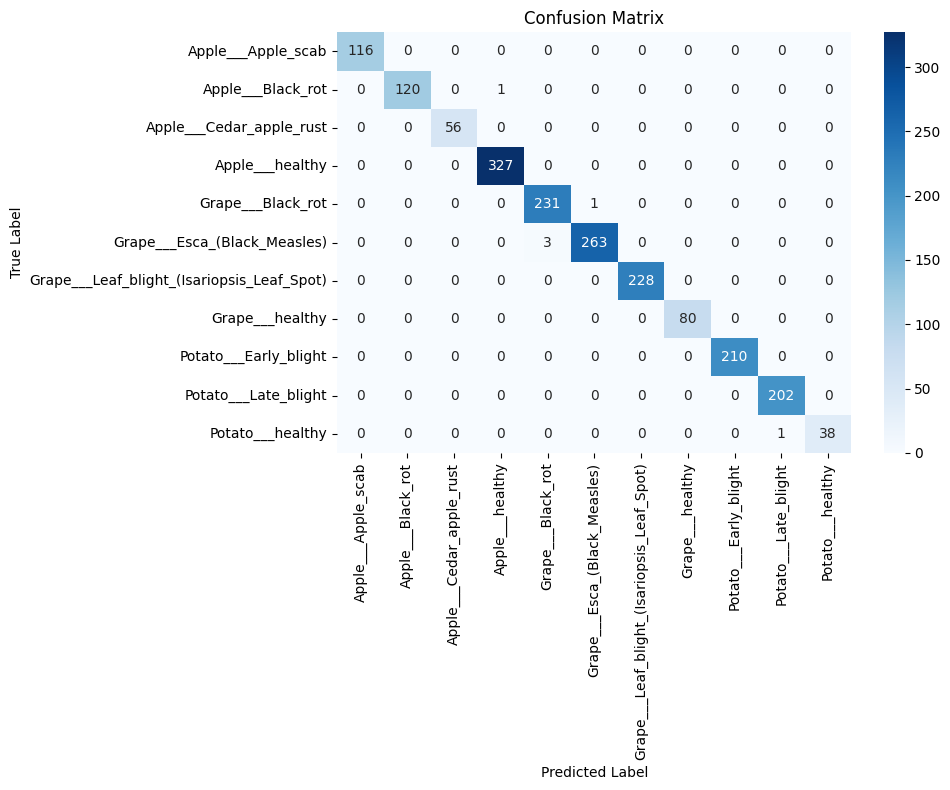

In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

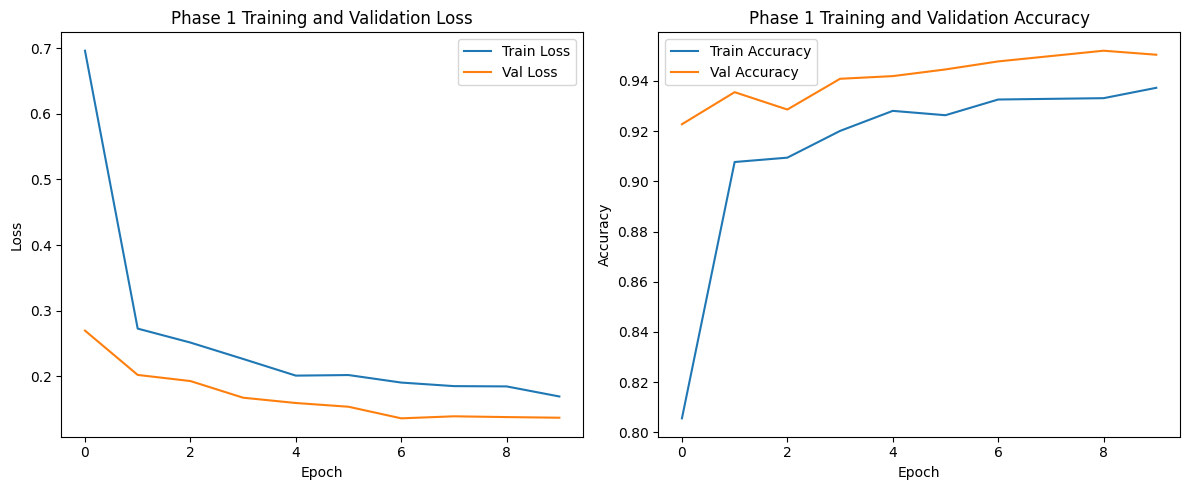

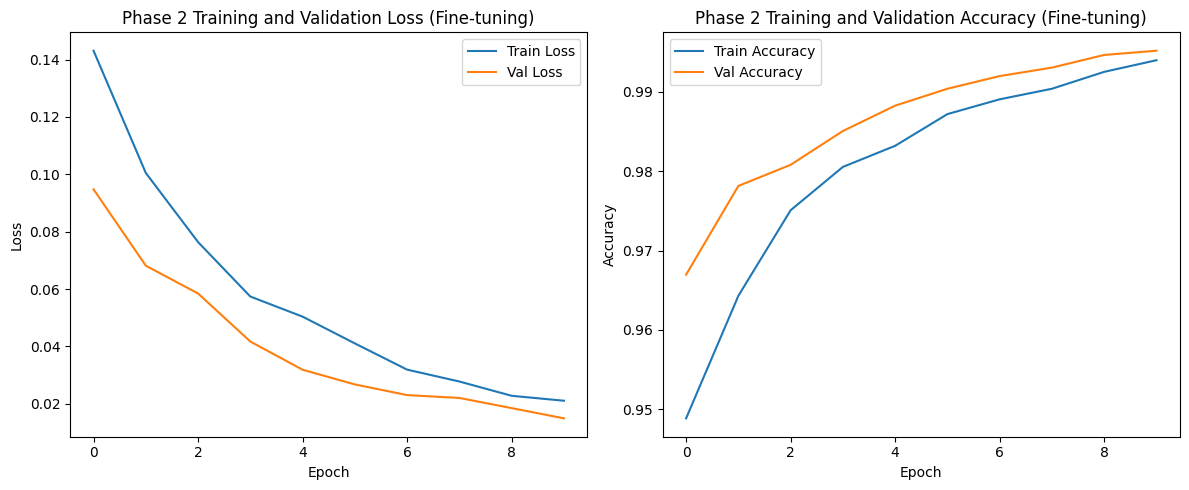

In [ ]:
# Plot training and validation history for Phase 1
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_phase1['train_loss'], label='Train Loss')
plt.plot(history_phase1['val_loss'], label='Val Loss')
plt.title('Phase 1 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_phase1['train_acc'], label='Train Accuracy')
plt.plot(history_phase1['val_acc'], label='Val Accuracy')
plt.title('Phase 1 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Plot training and validation history for Phase 2
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_phase2['train_loss'], label='Train Loss')
plt.plot(history_phase2['val_loss'], label='Val Loss')
plt.title('Phase 2 Training and Validation Loss (Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_phase2['train_acc'], label='Train Accuracy')
plt.plot(history_phase2['val_acc'], label='Val Accuracy')
plt.title('Phase 2 Training and Validation Accuracy (Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

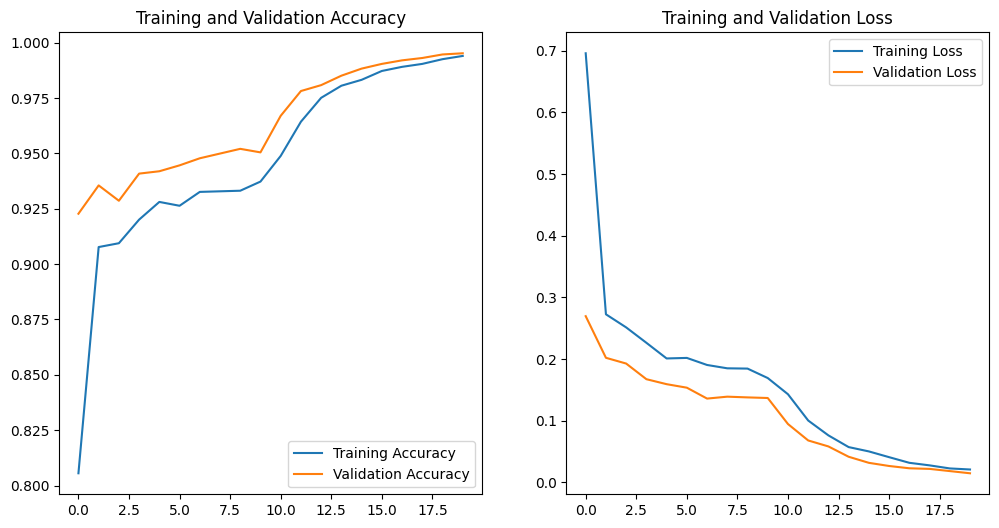

In [ ]:
# Combine histories from both phases for plotting
acc = history_phase1['train_acc'] + history_phase2['train_acc']
val_acc = history_phase1['val_acc'] + history_phase2['val_acc']
loss = history_phase1['train_loss'] + history_phase2['train_loss']
val_loss = history_phase1['val_loss'] + history_phase2['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()